Energy shift at 237 keV: 1.22148 keV
Energy shift at 250 keV: 1.196 keV
Energy shift at 352 keV: 1.03132 keV
[1.45475167e-01 3.26531732e+01 6.59068055e-02 3.50698310e-02
 9.81298636e-03 1.48324614e-03 2.04497463e-05 1.44803477e-01]
[18.08618654 29.74662583 22.0934774  26.15800161 30.1383374  30.95181215
 30.37736735 10.38702819  1.78307171 17.89895266  0.72921774  0.07198662
  0.17104439]
[ 0.15833913  3.96831816  7.1769963  12.78449871]
[]
[0.3214989  6.24420461]
[13.46762256  7.4841979   5.82935229  1.64402669  1.5588835   3.08524907
  0.78590268]
[]
[0.10083607 0.10695681]


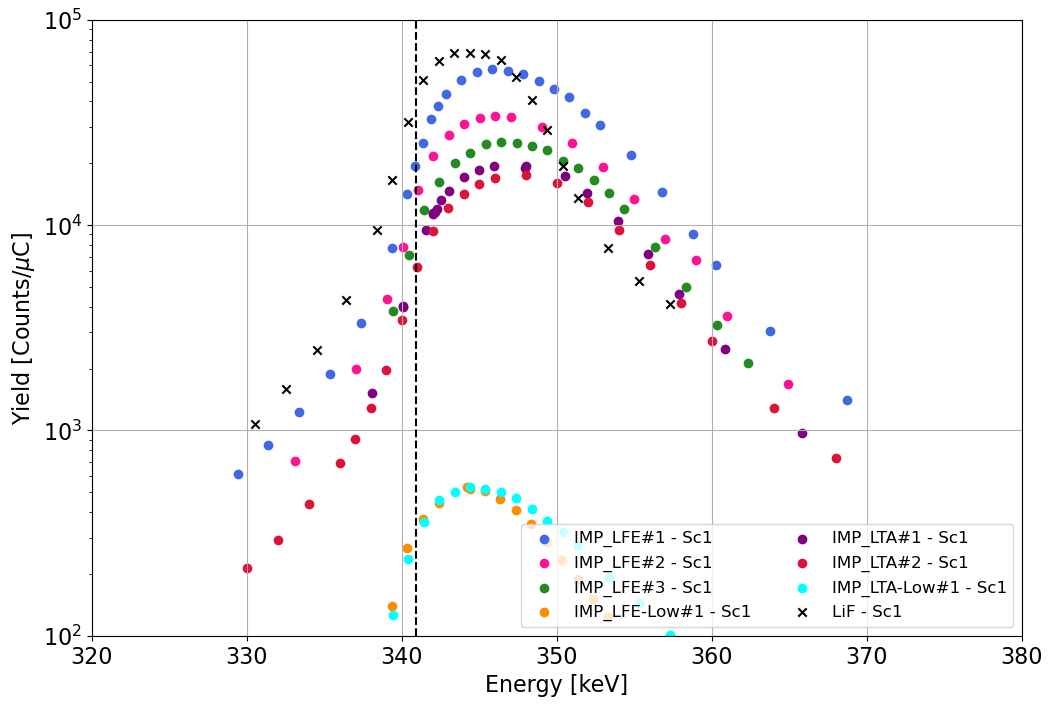

In [1]:
from SRIM import SRIM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 16

def yld(target):
    df = pd.read_csv(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target}.csv")
    df = df[df["Scan"] == "Scan 1"]

    x, y, y_err = df["Energy"], df["Yield"], df["Yield Error"]
    mask = (~np.isnan(x)) & (x < 300)
    x_240 = x[mask].to_numpy()
    y_240 = y[mask].to_numpy()
    yerr_240 = y_err[mask].to_numpy()
    eff_240 = 0.68934702

    mask = (~np.isnan(x)) & (x > 300)
    x_340 = x[mask].to_numpy()
    y_340 = y[mask].to_numpy()
    yerr_340 = y_err[mask].to_numpy()
    eff_340 = 0.004478220000000001

    return np.concatenate((x_240, x_340)), np.concatenate((y_240/eff_240, y_340/eff_340))

def yld_low(target):
    df = pd.read_csv(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target}.csv")
    df = df[df["Scan"] == "Scan 1"]

    x, y, y_err = df["Energy"], df["Yield"], df["Yield Error"]
    mask = (~np.isnan(x)) & (x < 300)
    x_240 = x[mask].to_numpy()
    y_240 = y[mask].to_numpy()
    yerr_240 = y_err[mask].to_numpy()
    eff_240 = 0.68934702

    mask = (~np.isnan(x)) & (x > 300)
    x_340 = x[mask].to_numpy()
    y_340 = y[mask].to_numpy()
    yerr_340 = y_err[mask].to_numpy()
    eff_340 = 0.68934702

    return np.concatenate((x_240, x_340)), np.concatenate((y_240/eff_240, y_340/eff_340))

x_imp_lfe1, y_imp_lfe1 = yld("IMP_LFE#1")
x_imp_lfe2, y_imp_lfe2 = yld("IMP_LFE#2")
x_imp_lfe3, y_imp_lfe3 = yld("IMP_LFE#3")

x_imp_lta1, y_imp_lta1 = yld("IMP_LTA#1")
x_imp_lta2, y_imp_lta2 = yld("IMP_LTA#2")

x_imp_low_lta1, y_imp_low_lta1 = yld_low("IMP_LTA-Low#1")
x_imp_low_lfe, y_imp_low_lfe = yld_low("IMP_LFE-Low#1")

x_lif, y_lif = yld("LiF")

x_sudf2, y_sudf2 = yld("SUDF#2")
x_sudf3, y_sudf3 = yld("SUDF#3")
x_sudf4, y_sudf4 = yld("SUDF#4")
x_sudf5, y_sudf5 = yld("SUDF#5")


# Recover the data.csv file
x_zhang, y_zhang = np.loadtxt("/data0/biasissi/LUNA/19F+p_g+20Ne/Tests/Zhang_2022_pag_yields/data.csv", delimiter=",", unpack=True)
y_zhang = y_zhang/1e3  # convert to counts/uC
# cr_layer_shift = 0 # keV

H_in_Cr = SRIM("/data0/biasissi/LUNA/19F+p_g+20Ne/Data/STOPPING/H_in_Cr.stop") # MeV/nm
def effective_stopping_Cr(energy):
    return H_in_Cr.eval(energy)  # keV/50 nm

layer_width_nm = 50  # nm
# print the interp of energy shift at 237, 250 and 352 kev
print(f"Energy shift at 237 keV: {effective_stopping_Cr(237)/1e3*layer_width_nm} keV")
print(f"Energy shift at 250 keV: {effective_stopping_Cr(250)/1e3*layer_width_nm} keV")
print(f"Energy shift at 352 keV: {effective_stopping_Cr(352)/1e3*layer_width_nm} keV")




x_zhang = x_zhang - effective_stopping_Cr(x_zhang)/1e3*layer_width_nm  # counts/uC


eff_long = 0.68934702
df_long = pd.read_csv("/data0/biasissi/LUNA/19F+p_g+20Ne/Tests/Zhang_2022_pag_yields/Yield_6130_total.csv")
x_long = df_long["Energy"].to_numpy()
y_long = df_long["Y"].to_numpy()/eff_long
targets = df_long["Target"].to_numpy()

mask = targets == "IMP_LFE#1"
x_long_imp_lfe1 = x_long[mask]
y_long_imp_lfe1 = y_long[mask]
print(y_long_imp_lfe1)

mask = targets == "IMP_LFE#2"
x_long_imp_lfe2 = x_long[mask]
y_long_imp_lfe2 = y_long[mask]
print(y_long_imp_lfe2)

mask = targets == "IMP_LFE#3"
x_long_imp_lfe3 = x_long[mask]
y_long_imp_lfe3 = y_long[mask]
print(y_long_imp_lfe3)

mask = targets == "IMP_LFE-Low#1"
x_long_imp_low_lfe = x_long[mask]
y_long_imp_low_lfe = y_long[mask]
print(y_long_imp_low_lfe)

mask = targets == "IMP_LTA#1"
x_long_imp_lta1 = x_long[mask]
y_long_imp_lta1 = y_long[mask]
print(y_long_imp_lta1)

mask = targets == "IMP_LTA#2"
x_long_imp_lta2 = x_long[mask]
y_long_imp_lta2 = y_long[mask]
print(y_long_imp_lta2)

mask = targets == "IMP_LTA-Low#1"
x_long_imp_low_lta1 = x_long[mask]
y_long_imp_low_lta1 = y_long[mask]
print(y_long_imp_low_lta1)

mask = targets == "SUDF#4"
x_long_sudf4 = x_long[mask]
y_long_sudf4 = y_long[mask]
print(y_long_sudf4)

plt.figure(figsize=(12,8))
plt.yscale("log")
plt.scatter(x_imp_lfe1, y_imp_lfe1, label="IMP_LFE#1 - Sc1", color="royalblue")
# plt.scatter(x_long_imp_lfe1, y_long_imp_lfe1, color="royalblue")
plt.scatter(x_imp_lfe2, y_imp_lfe2, label="IMP_LFE#2 - Sc1", color="deeppink")
# plt.scatter(x_long_imp_lfe2, y_long_imp_lfe2, color="deeppink")
plt.scatter(x_imp_lfe3, y_imp_lfe3, label="IMP_LFE#3 - Sc1", color="forestgreen")
# plt.scatter(x_long_imp_lfe3, y_long_imp_lfe3, color="forestgreen")
plt.scatter(x_imp_low_lfe, y_imp_low_lfe, label="IMP_LFE-Low#1 - Sc1", color="darkorange")
plt.scatter(x_imp_lta1, y_imp_lta1, label="IMP_LTA#1 - Sc1", color="purple")
# plt.scatter(x_long_imp_lta1, y_long_imp_lta1, color="purple")
plt.scatter(x_imp_lta2, y_imp_lta2, label="IMP_LTA#2 - Sc1", color="crimson")
# plt.scatter(x_long_imp_lta2, y_long_imp_lta2, color="crimson")
plt.scatter(x_imp_low_lta1, y_imp_low_lta1, label="IMP_LTA-Low#1 - Sc1", color="cyan")
# plt.scatter(x_long_imp_low_lta1, y_long_imp_low_lta1, color="cyan")
plt.scatter(x_lif, y_lif, label="LiF - Sc1", color="black", marker="x")
# plt.scatter(x_zhang, y_zhang, label=f"Zhang et al., PRL (2021)\n({layer_width_nm}-nm Cr-layer)", color="black")
# plt.scatter(x_sudf2, y_sudf2, label="SUDF#2 - Sc1", color="royalblue")
# plt.scatter(x_sudf3, y_sudf3, label="SUDF#3 - Sc1", color="deeppink")
# plt.scatter(x_sudf4, y_sudf4, label="SUDF#4 - Sc1", color="forestgreen")
# plt.scatter(x_sudf5, y_sudf5, label="SUDF#5 - Sc1", color="darkorange")

plt.axvline(214.8*20/19, color="black", linestyle="--")
plt.axvline(227.9*20/19, color="black", linestyle="--")
plt.axvline(323.9*20/19, color="black", linestyle="--")

plt.xlabel("Energy [keV]", fontsize=16)
plt.ylabel(r"Yield [Counts/$\mu$C]", fontsize=16)

plt.xlim(320, 380)
plt.ylim(1e2, 1e5)

plt.grid()
plt.legend(ncols=2, fontsize=12, loc="lower right")

# plt.annotate("LUNA points are rescaled\nby efficiency\n\nJUNA used implanted-Fe targets", xy=(0.24, 0.97), xycoords='axes fraction', fontsize=16, verticalalignment='top')

plt.savefig("/data0/biasissi/LUNA/19F+p_g+20Ne/Tests/Zhang_2022_pag_yields/Comparison_LUNA_JUNA_yields.png", dpi=500, bbox_inches='tight')

plt.show()

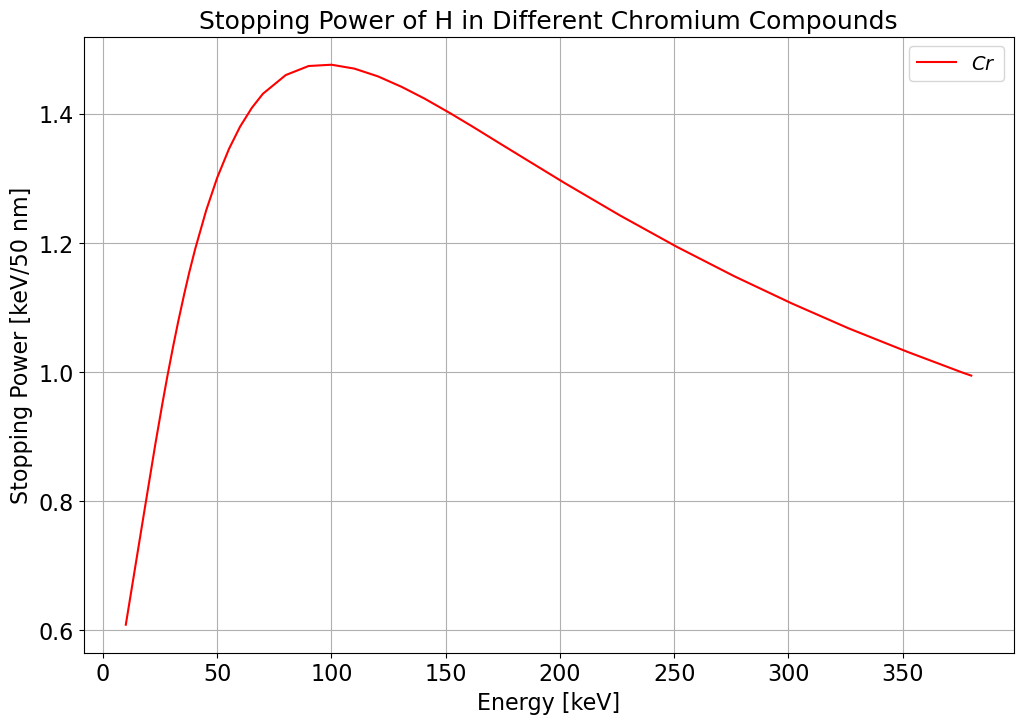

effective stoppower at 240 keV: 1.2156 keV/50 nm


In [2]:
from SRIM import SRIM

# Read the element stopping data
# H_in_Cr3C2 = SRIM("/data0/biasissi/LUNA/19F+p_g+20Ne/Data/STOPPING/H_in_Cr3C2.stop")
# H_in_CrO2 = SRIM("/data0/biasissi/LUNA/19F+p_g+20Ne/Data/STOPPING/H_in_CrO2.stop")
# H_in_CrO3 = SRIM("/data0/biasissi/LUNA/19F+p_g+20Ne/Data/STOPPING/H_in_CrO3.stop")
H_in_Cr = SRIM("/data0/biasissi/LUNA/19F+p_g+20Ne/Data/STOPPING/H_in_Cr.stop")

# # Get the effective stopping power for F implanted in Fe
# def effective_stopping_Fe(energy, n_inactive=1, n_active=3):
#     stoichiometry = n_inactive / n_active
#     return H_in_F.eval(energy) + stoichiometry * H_in_Fe.eval(energy)

# # Get the effective stopping power for F implanted in Ta
# def effective_stopping_Ta(energy, n_inactive=1, n_active=5):
#     stoichiometry = n_inactive / n_active
#     return H_in_F.eval(energy) + stoichiometry * H_in_Ta.eval(energy)

# # Get the effective stopping power for Cr3C2
# def effective_stopping_Cr3C2(energy):
#     print(H_in_Cr3C2.eval(energy))
#     return H_in_Cr3C2.eval(energy)

# # Get the effective stopping powers for CrO2
# def effective_stopping_CrO2(energy):
#     print(H_in_CrO2.eval(energy))
#     return H_in_CrO2.eval(energy)

# # Get the effective stopping powers for CrO3
# def effective_stopping_CrO3(energy):
#     print(H_in_CrO3.eval(energy))
#     return H_in_CrO3.eval(energy)

# Get the effective stopping powers for Cr
def effective_stopping_Cr(energy):
    # print(H_in_Cr.eval(energy))
    return H_in_Cr.eval(energy)

# effective_stopping_Cr3C2(214.8)
# effective_stopping_Cr3C2(227.9)
# effective_stopping_Cr3C2(323.9)

# effective_stopping_CrO2(214.8)
# effective_stopping_CrO2(227.9)
# effective_stopping_CrO2(323.9)

# effective_stopping_CrO3(214.8)
# effective_stopping_CrO3(227.9)
# effective_stopping_CrO3(323.9)

X = np.linspace(10, 380, 1000)
# Y_Cr3C2 = effective_stopping_Cr3C2(X)
# Y_CrO2 = effective_stopping_CrO2(X)
# Y_CrO3 = effective_stopping_CrO3(X)
Y_Cr = effective_stopping_Cr(X)

plt.figure(figsize=(12,8))
# plt.plot(X, Y_Cr3C2, label=r"$Cr_3C_2$", color="blue")
# plt.plot(X, Y_CrO2, label=r"$CrO_2$", color="orange")
# plt.plot(X, Y_CrO3, label=r"$CrO_3$", color="green")
plt.plot(X, Y_Cr/1e3*50, label=r"$Cr$", color="red")
plt.xlabel("Energy [keV]", fontsize=16)
plt.ylabel("Stopping Power [keV/50 nm]", fontsize=16)
plt.title("Stopping Power of H in Different Chromium Compounds", fontsize=18)
plt.legend(fontsize=14)
plt.grid()
plt.show()

print(f"effective stoppower at 240 keV: {effective_stopping_Cr(240)/1e3*50} keV/50 nm")